### Image Captioning with CNN + LSTM
Build an image captioning pipeline: use a pre-trained CNN (e.g. ResNet-18) as the encoder and an LSTM as the decoder. Train
on Flickr8k. Show sample captions, compare with ground truth, and evaluate with BLEU scores.

---

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import os
import random

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

In [24]:
import nltk
from nltk.translate.bleu_score import  corpus_bleu

In [25]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.12.0+cu126
CUDA available: True
Using device: cuda


---

### Data Loading

In [26]:
data_folder = "./data"
images_folder = os.path.join(data_folder, "Images")
captions_file = os.path.join(data_folder, "captions.txt")

# Image Data
image_files = os.listdir(images_folder)
print("Number of image files   :", len(image_files))

# Caption Data 
with open(captions_file, "r", encoding="utf-8") as f:
    lines = f.readlines()
print("Total Captions:", len(lines))

Number of image files   : 8091
Total Captions: 40456


In [27]:
# Convert caption lines into a clean dictionary : image -> captions 

captions_dict = {}

with open(captions_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

for line in lines[1:]:
    line = line.strip()
    
    if not line:
        continue

    image_name, caption = line.split(",", 1)
    caption = caption.lower().strip()

    if image_name not in captions_dict:
        captions_dict[image_name] = []


    captions_dict[image_name].append(caption)


---

### Building Vocabulary
using min-freq = 5 to remove the rare words to reduce noise in the data and balancing the traing time and accuracy 

In [28]:
# Count total unique words and common words to decide min_freq value 

from collections import Counter
word_counter = Counter()

for image_name, caption_list in captions_dict.items():
    for caption in caption_list:
        words = caption.split()
        word_counter.update(words)

print("Total unique words", len(word_counter))
print("Most common 10 words:", word_counter.most_common(10))


Total unique words 9180
Most common 10 words: [('a', 61752), ('.', 34212), ('in', 18965), ('the', 18249), ('on', 10732), ('is', 9345), ('and', 8851), ('dog', 8126), ('with', 7761), ('man', 7238)]


In [29]:
# Make a vocab with the word_freq >= min_freq

min_freq = 5
vocab_words = [word for word, count in word_counter.items() if count >= min_freq]

print("Total Words in Vocabulary: ", len(vocab_words))

Total Words in Vocabulary:  3036


In [30]:
# <PAD> makes captions equal length in a batch, and <UNK> handles unseen words

special_tokens = ["<PAD>", "<START>", "<END>", "<UNK>"]

# Index to String
itos = special_tokens + sorted(vocab_words)
vocab_size = len(itos)
# Ṣtring to Index
stoi = {word: idx for idx, word in enumerate(itos)}

# What we have acheived in this codeblock 
print("Vocabulary size after filtering:", len(itos))
print("Index of <PAD>  :", stoi["<PAD>"])
print("Index of <START>:", stoi["<START>"])


sample_words = ["dog", "man", "ball", "<PAD>", "<UNK>"]
for word in sample_words:
    print(f"{word} ->", stoi.get(word, "not in vocab"))


Vocabulary size after filtering: 3040
Index of <PAD>  : 0
Index of <START>: 1
dog -> 797
man -> 1572
ball -> 195
<PAD> -> 0
<UNK> -> 3


In [31]:
# Encoding Captions - Convert caption text into integer token sequences for the model

def encode_caption(caption, stoi):
    words = caption.split()
    tokens = [stoi["<START>"]]

    for word in words:
        if word in stoi:
            tokens.append(stoi[word])
        else:
            tokens.append(stoi["<UNK>"])

    tokens.append(stoi["<END>"])
    return tokens


In [32]:
# Create a PyTorch Dataset that returns one image and one encoded caption

# Resize images in dataset to 224*224 and values 0-225 to 0-1
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create Training Pairs - (img, caption)
all_pairs = []

for image_name, caption_list in captions_dict.items():
    for caption in caption_list:
        all_pairs.append((image_name, caption))

print("Total image-caption pairs:", len(all_pairs))
print("Sample pair:", all_pairs[0])

Total image-caption pairs: 40455
Sample pair: ('1000268201_693b08cb0e.jpg', 'a child in a pink dress is climbing up a set of stairs in an entry way .')


In [33]:
# Create a custom PyTorch Dataset for image-caption learning
# Dataset returns tensors because neural networks cannot train on raw PIL images or raw strings

class Flickr8kDataset(Dataset):

    def __init__(self, pairs, images_folder, stoi, transform=None):
        self.pairs = pairs
        self.images_folder = images_folder
        self.stoi = stoi
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_name, caption = self.pairs[idx]
        image_path = os.path.join(self.images_folder, image_name)

        # Convert it to 3 Channels 
        image = Image.open(image_path).convert("RGB")

        # Convert Image to Tensor
        if self.transform is not None:
            image = self.transform(image)
        
        # Convert Captions to tensor 
        caption_ids = encode_caption(caption, self.stoi)
        caption_tensor = torch.tensor(caption_ids, dtype=torch.long)

        return image, caption_tensor, image_name , caption



In [34]:
# load dataset 
dataset = Flickr8kDataset(pairs=all_pairs, images_folder=images_folder, stoi=stoi, transform=transform)

# Verification
sample_image_tensor, sample_caption_tensor, sample_image_name, sample_caption_text = dataset[0]
print("Sample image name:", sample_image_name)
print("Original caption:", sample_caption_text)
print("Image tensor shape:", sample_image_tensor.shape)
print("Caption tensor shape:", sample_caption_tensor.shape)
print("First 10 caption token IDs:", sample_caption_tensor[:10].tolist())

Sample image name: 1000268201_693b08cb0e.jpg
Original caption: a child in a pink dress is climbing up a set of stairs in an entry way .
Image tensor shape: torch.Size([3, 224, 224])
Caption tensor shape: torch.Size([20])
First 10 caption token IDs: [1, 61, 549, 1330, 61, 1928, 821, 1363, 583, 2872]


In [35]:
def caption_collate_fn(batch):

    images = []
    captions = []
    image_names = []
    raw_captions = []

    for image, caption, image_name, raw_caption in batch:
        images.append(image)
        captions.append(caption)
        image_names.append(image_name)
        raw_captions.append(raw_caption)

    images = torch.stack(images)

    lengths = [len(caption) for caption in captions]

    padded_captions = nn.utils.rnn.pad_sequence(
        captions,
        batch_first=True,
        padding_value=stoi["<PAD>"]
    )

    return (
        images,
        padded_captions,
        lengths,
        image_names,
        raw_captions
    )

In [36]:
data_loader = DataLoader(
    dataset,
    batch_size = 32,
    shuffle = True,
    collate_fn = caption_collate_fn
)

# # Verify 
sample_images, sample_captions, sample_lengths, sample_image_names, sample_raw_captions = next(iter(data_loader))

print(sample_images.shape)
print(sample_captions.shape)


torch.Size([32, 3, 224, 224])
torch.Size([32, 21])


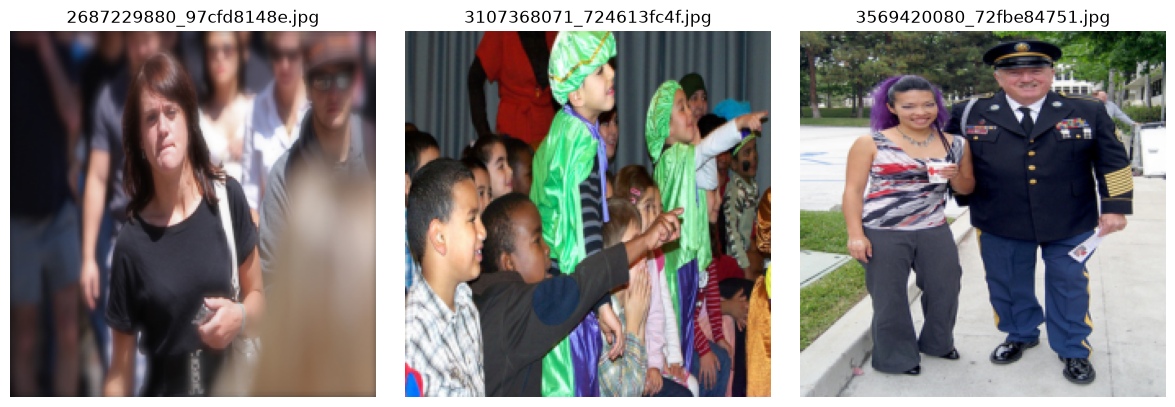

In [37]:
# Visualization
plt.figure(figsize=(12, 4))

for i in range(3):
    image = sample_images[i].permute(1,2, 0).numpy()

    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(sample_image_names[i])

plt.tight_layout()
plt.show()

---

### Models 

In [38]:
# Encoder - Resnet- 18
# The encoder transforms raw image pixels into a meaningful, low-dimensional visual feature vector that aligns with our text embedding space.
 
class EncoderCNN(nn.Module):

    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Remove final layer 
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])

        # Linear layer
        self.linear = nn.Linear(512, embed_size)

        # Freeze pretrained ResNet weights so we only train the linear layer and decoder
        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, images):
        # resnet output shape: (batch, 512, 1, 1)
        features = self.resnet(images)
        # Flatten the features to shape: (batch, 512)
        features = features.view(features.size(0), -1)

        return self.linear(features)

    

In [39]:
from torch import embedding
# Decoder - LSTM 
# LSTM decoder uses the image representation as the initial timestep context and autoregressively processes the caption sequence to predict subsequent tokens.


class DecoderRNN(nn.Module):

    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()

        # Embed token IDs to dense vectors of embeded_size (256)
        self.embedding  = nn.Embedding(vocab_size, embed_size)

        # LSTM layer handling sequential input
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)

        # Linear layer to project LSTM hidden state back to vocabulary size        
        self.linear = nn.Linear(hidden_size, vocab_size)

    
    def forward(self, features, captions):
        # We don't embed the very last token because it has no "next word" to predict.
        embeddings = self.embedding(captions[:, :-1])
        features = features.unsqueeze(1)
        inputs = torch.cat((features, embeddings), dim=1)
        hiddens, _ = self.lstm(inputs)
        outputs = self.linear(hiddens)
        return outputs



In [40]:
encoder = EncoderCNN(embed_size=256).to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(itos)).to(device)

---